In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from pandas.plotting import table

%matplotlib inline
plt.rcParams["figure.figsize"] = [12,8]

np.random.seed(42)

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Логистическая регрессия

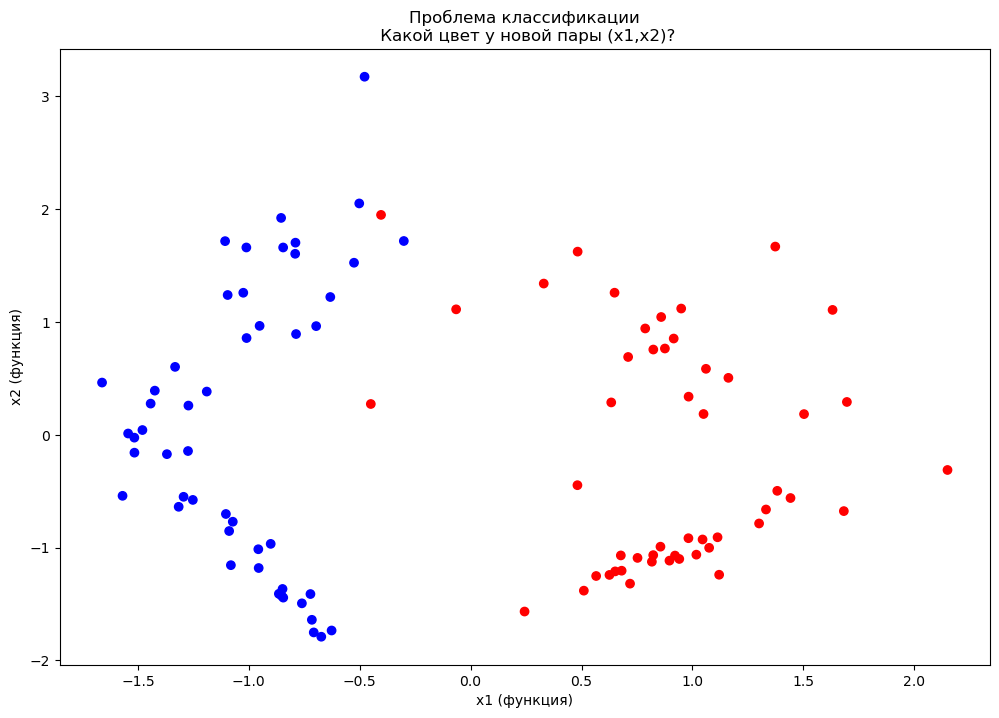

In [3]:
X, y = datasets.make_classification(n_features=2, n_informative=2, n_redundant=0, n_repeated=0, random_state=1)

colors = ['red' if y_i else 'blue' for y_i in y]
plt.scatter(X[:, 0], X[:, 1], c=colors)
plt.title("Проблема классификации\n Какой цвет у новой пары (x1,x2)?")
plt.xlabel("x1 (функция)")
plt.ylabel("x2 (функция)");

# Линейный классификатор

Построим случайную прямую. Насколько хорошо она описывает данные?

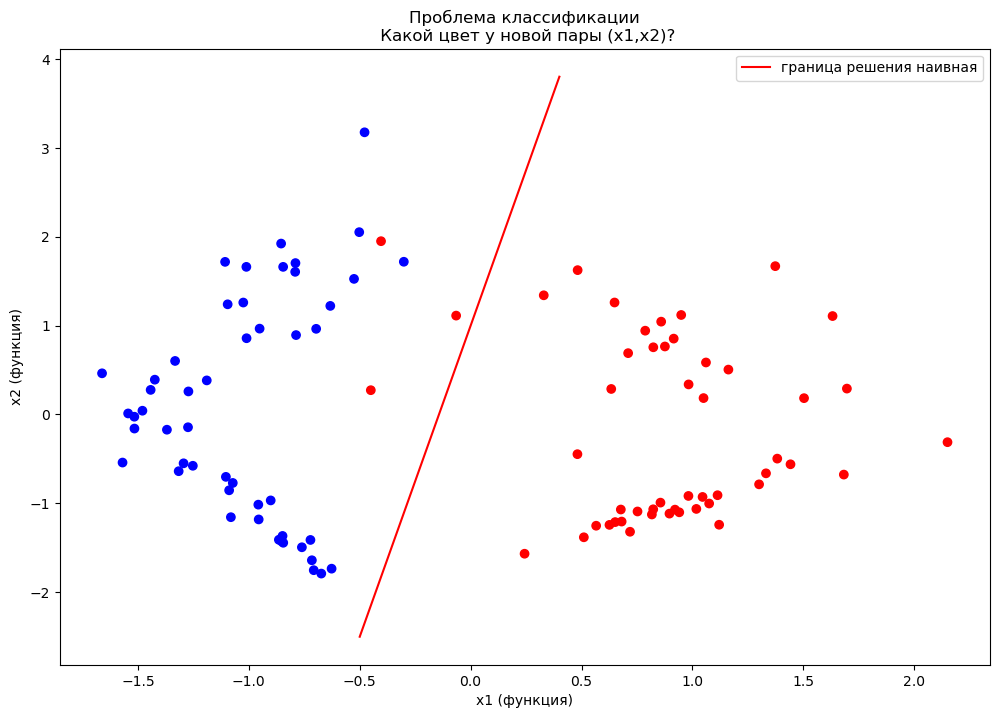

In [4]:
x_naive = np.arange(-0.5, 0.5, 0.1)
y_naive = 7 * x_naive + 1

plt.scatter(X[:, 0], X[:, 1], c=colors)
plt.title("Проблема классификации\n Какой цвет у новой пары (x1,x2)?")
plt.xlabel("x1 (функция)")
plt.ylabel("x2 (функция)")
plt.plot(x_naive, y_naive, c='red', label="граница решения наивная")
plt.legend()

## Как принимается решение

Простой вариант - узнать, с какой стороны от гиперплоскости находится точка

$$\hat{y} = \text{sign}(x\theta)$$


In [5]:
w = np.array([7, -1, 1]) # Ax + By + C = 0

# Замечание: расстояние от точки (x0, y0) до прямой Ax + By + C это abs(Ax0 + By0 + C) / sqrt(A^2 + B^2)

def predict(x, w):
    return np.sign(x.dot(w))

x_pred = np.hstack([np.random.rand(10, 2) * 4 - 2, np.ones(10).reshape(-1, 1)])
y_pred = predict(x_pred, w)

print(x_pred.shape)
print(y_pred.shape)

(10, 3)
(10,)


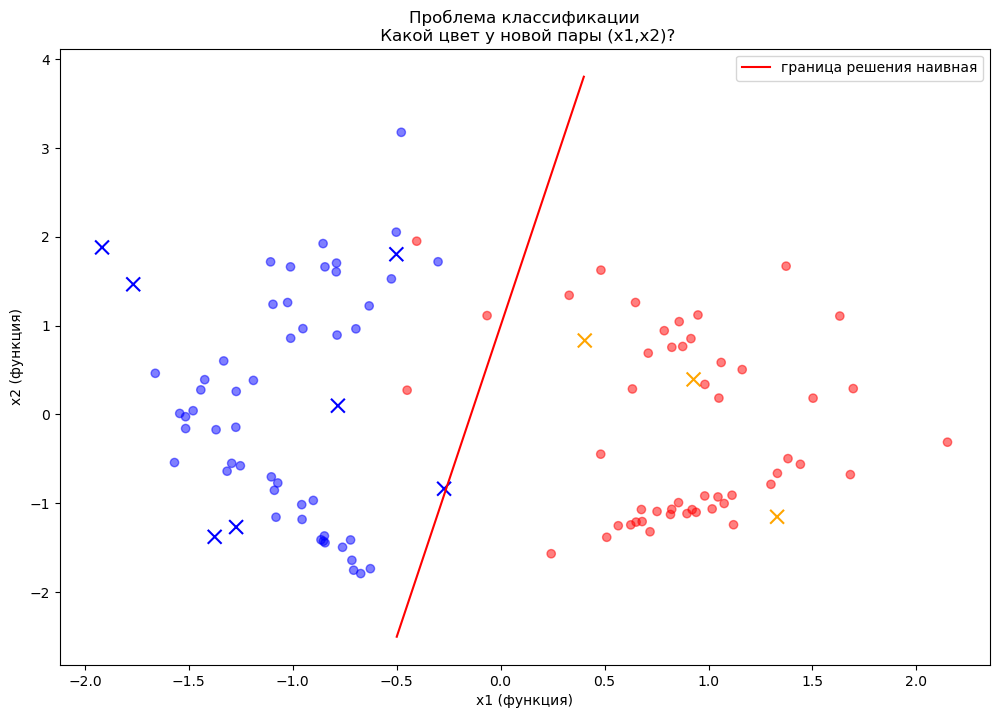

In [6]:
x_naive = np.arange(-0.5, 0.5, 0.1)
# naive boundary
y_naive = 7 * x_naive + 1

plt.scatter(x_pred[:, 0], x_pred[:, 1], c=['orange' if y_i > 0 else 'blue' for y_i in y_pred], marker='x', s=100)
plt.title("Проблема классификации\n Какой цвет у новой пары (x1,x2)?")
plt.xlabel("x1 (функция)")
plt.ylabel("x2 (функция)")
plt.scatter(X[:, 0], X[:, 1], c=colors, alpha=0.5)
plt.plot(x_naive, y_naive, c='red', label="граница решения наивная")
plt.legend()

## Как оценить результат - простой вариант

Отступ (margin) - величина $M_i = y_i \cdot x_i\theta$ (для $y = 1$ или $y = -1$), где $x_i$ - элемент обучающей выборки, $y_i$ - его класс

$$M_i \leq 0 \Rightarrow y_i \neq \hat{y_i}$$
$$M_i > 0 \Rightarrow y_i = \hat{y_i}$$

Функция потерь zero-one loss:
$$ f(x) = \begin{cases}
      1, & \text{если}\space \hat{y} \neq y, \\
      0, & \text{если}\space \hat{y} = y
    \end{cases}
$$ 

Эмпирический риск:
$$Q(\theta, x) = \frac{1}{n} \sum_{i=1}^{n} f(x) = \frac{1}{n} \sum_{i=1}^{n}[M_i < 0]$$

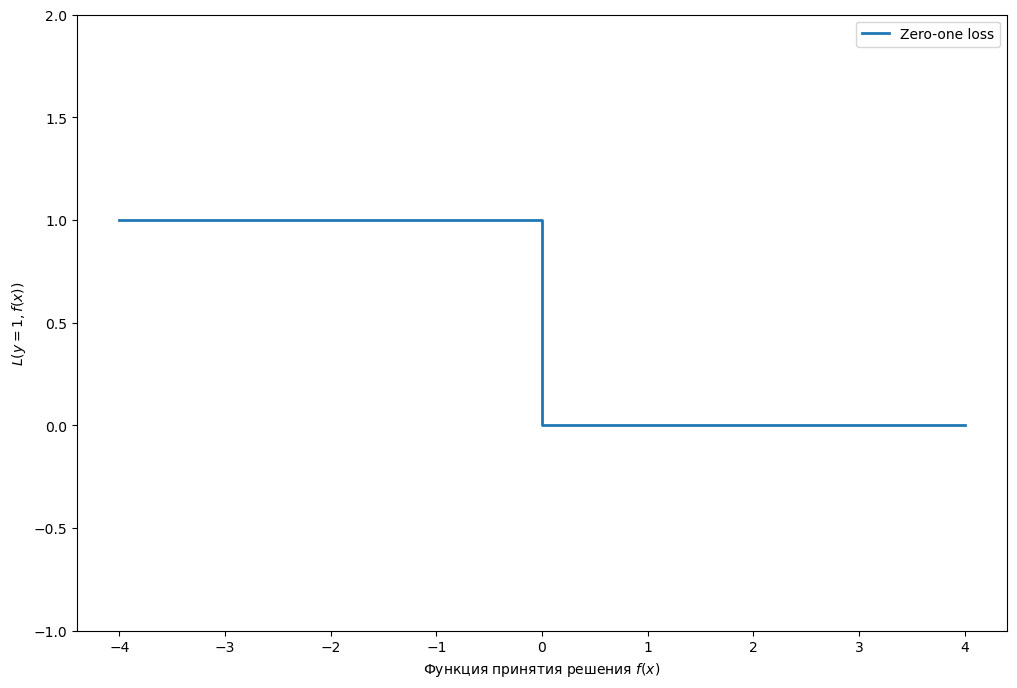

In [7]:
xmin, xmax = -4, 4
xx = np.linspace(xmin, xmax, 100)
lw = 2
plt.plot([xmin, 0, 0, xmax], [1,1,0,0], lw=lw, label='Zero-one loss')
# plt.plot(xx, np.log2(1 + np.exp(-xx)), color='green', lw=lw, label="Log loss")
plt.xlabel(r"Функция принятия решения $f(x)$")
plt.legend(loc="upper right")
plt.ylabel("$L(y=1, f(x))$")
plt.ylim((-1, 2));

In [8]:
from sklearn.metrics import zero_one_loss

print(y)
print(y_pred)
zero_one_loss([0,0,1,1], [0,0,0,1]) # средняя грубая ошибка (на сколько хороши наши предсказания)

[1 1 0 0 0 1 1 1 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0
 0 1 1 1 0 0 1 1 1 0 1 0 1 1 0 1 0 0 0 0 1 1 1 1 0 1 1 0 1 1 1 0 0 0 0 1 1
 1 1 0 0 1 1 1 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 0 0 1 0]
[-1.  1. -1. -1.  1. -1.  1. -1. -1. -1.]


0.25

## Переформулируем задачу
Вместо класса будем предсказывать вероятность принадлежности классу

$$\hat{p} = \sigma(x\theta) $$

где 

$$\sigma(t)=\frac{1}{1 + exp(-t)}$$

Пусть P вероятность принадлежности к классу. Тогда отношение шансов (odds ratio):


$$ OR = \frac{P} {1 - P} $$ <br>
$$ log {OR} \in R$$

Научились делать предсказание для $log {OR}$ с помощью линейной регрессии. Что делать теперь?

$$ log OR = x \theta$$

$$ P(y_i = 1 | x, \theta) = \frac {OR} {1 + OR} = \frac{e^{x\theta}} {1 + e^{x\theta}} = \sigma(x\theta) $$

$$ P(y_i = -1 | x, \theta) = ... = \sigma(-x\theta)$$

$$ P(y | x, \theta) = \prod_i {P(y = y_i | x_i, \theta)}$$


### Упражнение
упростите последнее выражение
- возьмем логарифм
- используем правило для логарифма произведения
- используем правило для логарифма частного

В результате должно получиться:
$ \log P(y | x, \theta) = -\sum {\log {(1 + e ^ {-y_i x \theta})}}$

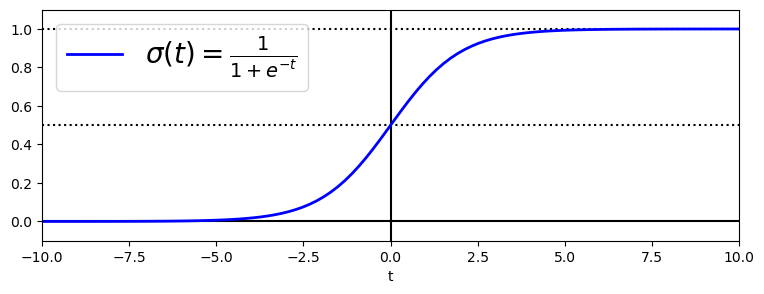

In [9]:
# Сигмоида
t = np.linspace(-10, 10, 100)
sig = 1 / (1 + np.exp(-t))
plt.figure(figsize=(9,3))
plt.plot([-10, 10], [0, 0], "k-")
plt.plot([-10, 10], [0.5, 0.5], "k:")
plt.plot([-10, 10], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \frac{1}{1 + e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left", fontsize=20)
plt.axis([-10, 10, -0.1, 1.1])
plt.show()

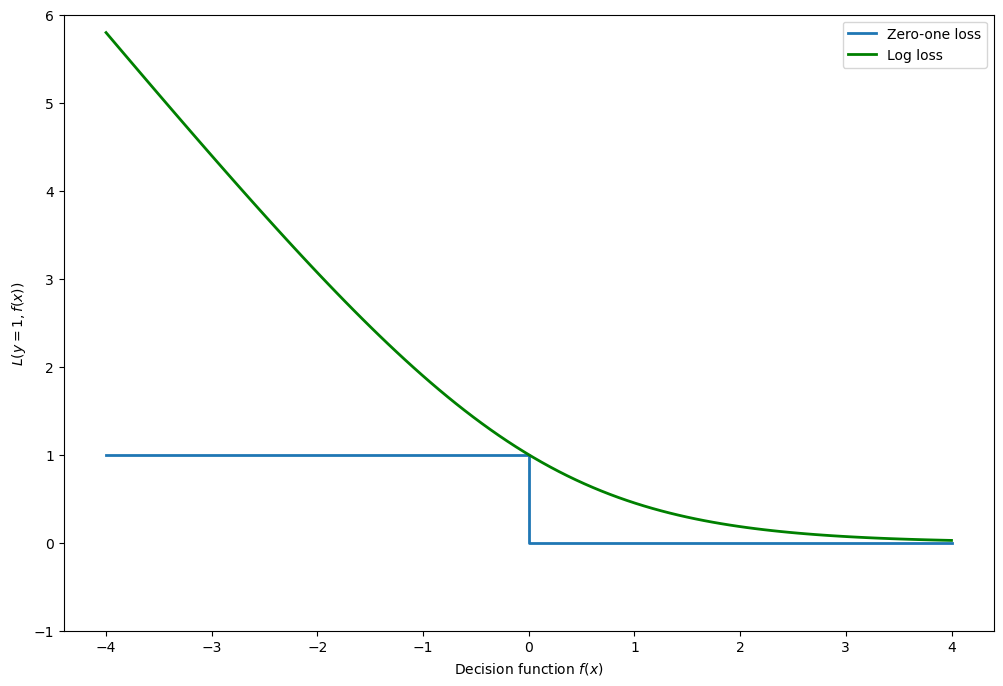

In [10]:
xmin, xmax = -4, 4
xx = np.linspace(xmin, xmax, 100)
lw = 2
plt.plot([xmin, 0, 0, xmax], [1, 1, 0, 0], lw=lw, label="Zero-one loss")
plt.plot(xx, np.log2(1 + np.exp(-xx)), color='green', lw=lw, label="Log loss")
plt.xlabel(r"Decision function $f(x)$")
plt.legend(loc="upper right")
plt.ylabel("$L(y=1, f(x))$")
plt.ylim((-1, 6));

# В sklearn

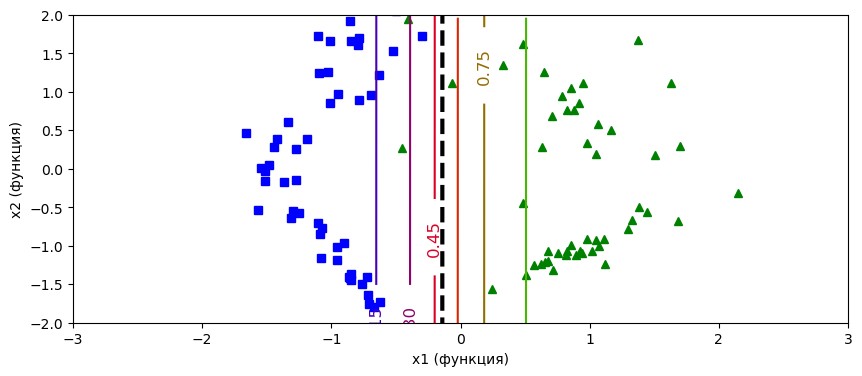

In [11]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(solver="lbfgs")
log_reg.fit(X, y)

x0, x1 = np.meshgrid(
    np.linspace(-2, 2, 500).reshape(-1, 1),
    np.linspace(-3, 3, 200).reshape(-1, 1)
)

X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = log_reg.predict_proba(X_new)

plt.figure(figsize=(10, 4))
plt.plot(X[y==0, 0], X[y==0, 1], "bs")
plt.plot(X[y==1, 0], X[y==1, 1], "g^")
zz = y_proba[:, 1].reshape(x0.shape)
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
left_right = np.array([-3, 3])
boundary = -(log_reg.coef_[0][0] * left_right + log_reg.intercept_[0]) / log_reg.coef_[0][1]
plt.clabel(contour, inline=1, fontsize=12)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.xlabel("x1 (функция)")
plt.ylabel("x2 (функция)")
plt.axis([-3, 3, -2, 2])
# plt.savefig("pics/descision.pdf")
plt.show()

## Регуляризация
- $L_1$
- $L_2$

К функционалу ошибки добавляем некоторый функционал от $\theta$:

$$Q + \lambda \theta ^ 2$$

Возьмем $C = \frac {1} {\lambda}$ и получим оптимизационную задачу:
$$ \theta = \arg min_{theta} {Q(x, y, \theta)} = C * Q(x, y, \theta) + \theta ^ 2$$


# Пример

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [13]:
def quality_report(prediction, actual):
    print("Accuracy: {:.3f}\nPrecission: {:.3f}\nRecall: {:.3f}\nf1_score: {:.3f}".format(
        accuracy_score(prediction, actual),
        precision_score(prediction, actual),
        recall_score(prediction, actual),
        f1_score(prediction, actual),
    ))

In [14]:
data = pd.read_csv("data/column_2C_weka.csv")

# перекручиваем целевую
data['class'] = data['class'].apply(lambda x: 1 if x=='Abnormal' else 0)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(['class'], axis=1), data['class'], test_size=0.20, random_state=42, stratify=data['class']
)

# стандартизируем
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Учим knn
knn = KNeighborsClassifier(n_neighbors=40)
knn.fit(X_train_scaled, y_train)

print("Train quality:")
quality_report(knn.predict(X_train_scaled), y_train)
print("Test quality:")
quality_report(knn.predict(X_test_scaled), y_test)

Train quality:
Accuracy: 0.835
Precission: 0.875
Recall: 0.880
f1_score: 0.878
Test quality:
Accuracy: 0.823
Precission: 0.905
Recall: 0.844
f1_score: 0.874


In [15]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

log_reg.fit(X_train_scaled, y_train)
print("Train quality:")
quality_report(log_reg.predict(X_train_scaled), y_train)
print("Test quality:")
quality_report(log_reg.predict(X_test_scaled), y_test)

Train quality:
Accuracy: 0.847
Precission: 0.881
Recall: 0.892
f1_score: 0.886
Test quality:
Accuracy: 0.887
Precission: 0.929
Recall: 0.907
f1_score: 0.918


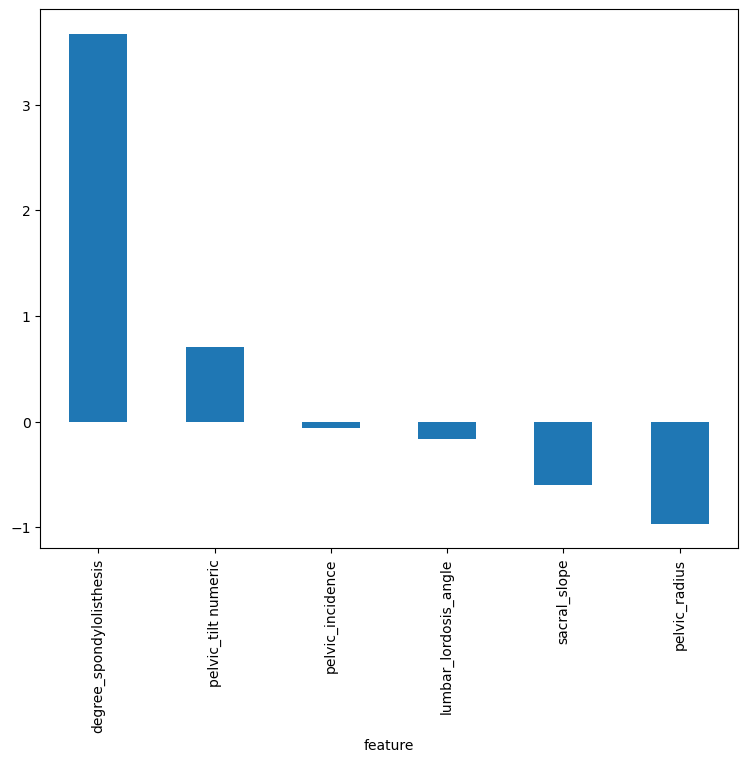

In [16]:
featureImportance = pd.DataFrame({"feature": data.drop('class', axis=1).columns,
                                  "importance": log_reg.coef_[0]})

featureImportance.set_index('feature', inplace=True)
featureImportance.sort_values(["importance"], ascending=False, inplace=True)
featureImportance["importance"].plot(kind="bar", figsize=(9, 7));

# Где же вероятности?

In [17]:
knn.predict_proba(X_test_scaled)[:10]

array([[0.425, 0.575],
       [0.475, 0.525],
       [0.1  , 0.9  ],
       [0.575, 0.425],
       [0.8  , 0.2  ],
       [0.025, 0.975],
       [0.575, 0.425],
       [0.1  , 0.9  ],
       [0.8  , 0.2  ],
       [0.425, 0.575]])

In [20]:
log_reg.predict(X_test_scaled)[:10]

array([1, 0, 1, 0, 0, 1, 0, 0, 0, 1])

In [24]:
(log_reg.predict_proba(X_test_scaled)[:10][:, 1]>0.5).astype(int)

array([1, 0, 1, 0, 0, 1, 0, 0, 0, 1])

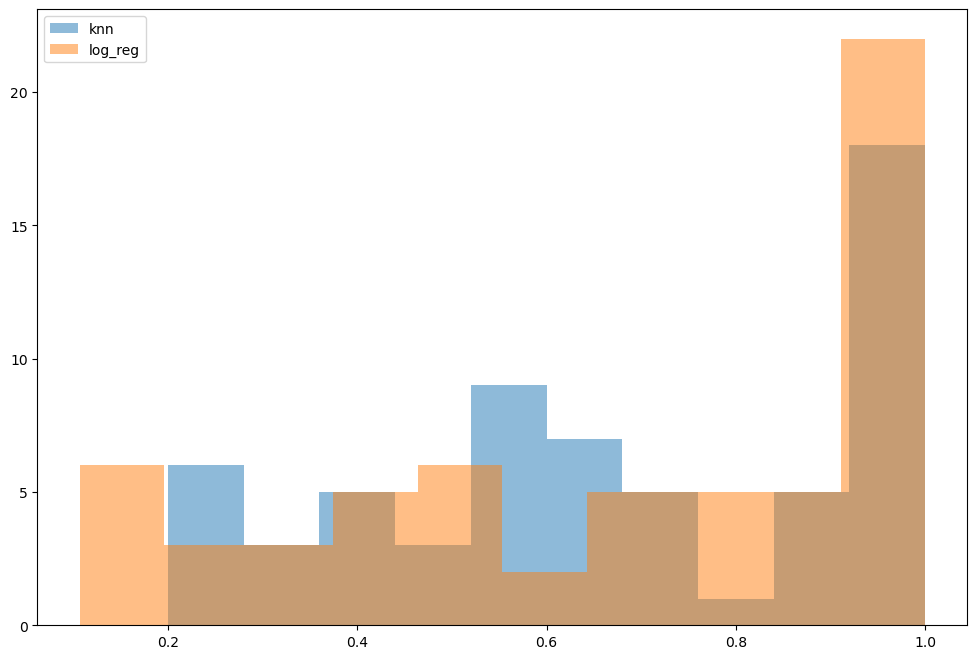

In [27]:
plt.hist(knn.predict_proba(X_test_scaled)[:, 1], alpha=0.5, label="knn");
plt.hist(log_reg.predict_proba(X_test_scaled)[:, 1], alpha=0.5, label="log_reg");
plt.legend()

In [28]:
 quality_report(knn.predict(X_test_scaled), y_test)

Accuracy: 0.823
Precission: 0.905
Recall: 0.844
f1_score: 0.874


In [29]:
quality_report(knn.predict_proba(X_test_scaled)[:, 1]>0.6, y_test)

Accuracy: 0.742
Precission: 0.738
Recall: 0.861
f1_score: 0.795


In [30]:
quality_report(knn.predict_proba(X_test_scaled)[:, 1]>0.2, y_test)

Accuracy: 0.710
Precission: 1.000
Recall: 0.700
f1_score: 0.824


In [31]:
quality_report(log_reg.predict_proba(X_test_scaled)[:, 1]>0.6, y_test)

Accuracy: 0.903
Precission: 0.881
Recall: 0.974
f1_score: 0.925


Получается неприятная ситуация. Все метрики, которые мы обсуждали, зависят от того, какой порог выставить. Это не очень круто. Хотелось бы получить что-то универсально, не зависящее от порога. 

Одним из способов оценить модель в целом, не привязываясь к конкретному порогу, является $ROC-AUC$ — площадь (Area Under Curve) под кривой ошибок. Данная кривая представляет из себя линию от $(0,0)$ до $(1,1)$ в координатах $True Positive Rate (TPR)$ и $False Positive Rate (FPR)$:

True Positive Rate: $$TPR = \frac{TP}{TP + FN}$$

False Positive Rate: $$FPR = \frac{FP}{FP + TN}$$

$TPR$ нам уже известна, это полнота, а $FPR$ показывает, какую долю из объектов negative класса алгоритм предсказал неверно. В идеальном случае, когда классификатор не делает ошибок $(FPR = 0, TPR = 1)$ мы получим площадь под кривой, равную единице; в противном случае, когда классификатор случайно выдает вероятности классов, $ROC-AUC$ будет стремиться к $0.5$, так как классификатор будет выдавать одинаковое количество $TP$ и $FP$.

In [36]:
threshoulds

array([       inf, 0.99999934, 0.73101785, 0.71515521, 0.60329145,
       0.57028185, 0.52695855, 0.44573906, 0.42243635, 0.37919568,
       0.34525042, 0.33921763, 0.31417777, 0.10689372])

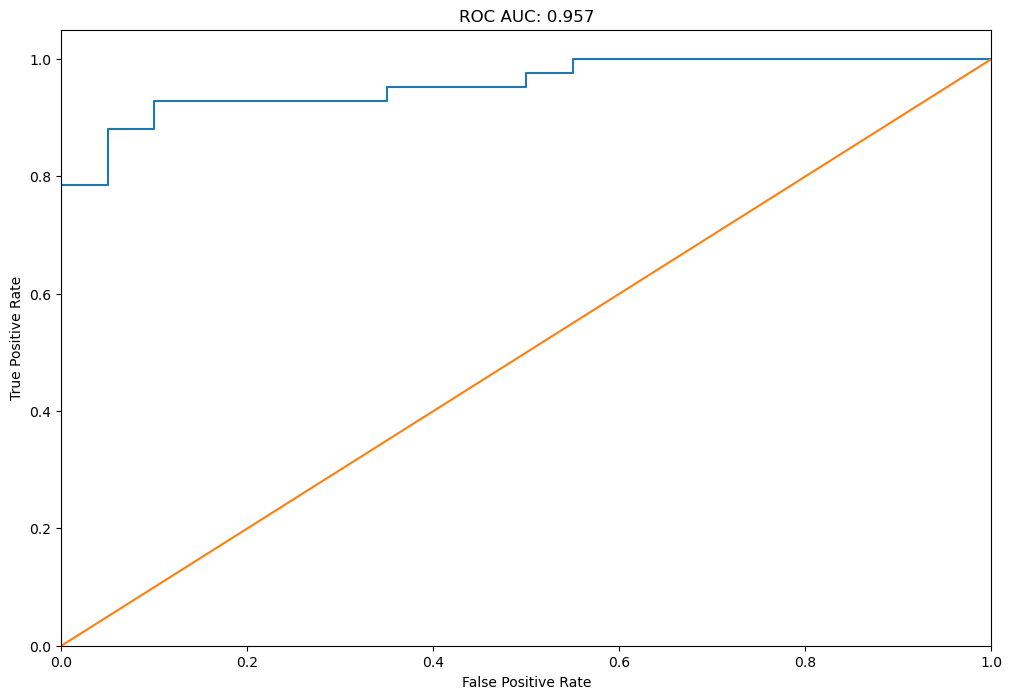

In [38]:
# подгружаем из пакета метрику roc_auc 
# и функцию для строительства кривой
from sklearn.metrics import roc_auc_score, roc_curve

# перебираем пороги и ищем для каждого fpr и tpr: 
prediction = log_reg.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, prediction)
auc_score = roc_auc_score(y_test, prediction)
# Рисуем картиночку
plt.plot(fpr, tpr, label='ROC curve ')
plt.plot([0, 1], [0, 1])
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC: {:.3f}'.format(auc_score))
plt.show()

In [34]:
def plot_roc_curve(prob_prediction, actual):
    fpr, tpr, threshoulds = roc_curve(y_test, prob_prediction)
    auc_score = roc_auc_score(y_test, prob_prediction)

    plt.plot(fpr, tpr, label='ROC curve')
    plt.plot([0, 1], [0, 1])
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC: {:.3f}'.format(auc_score))
    plt.show()

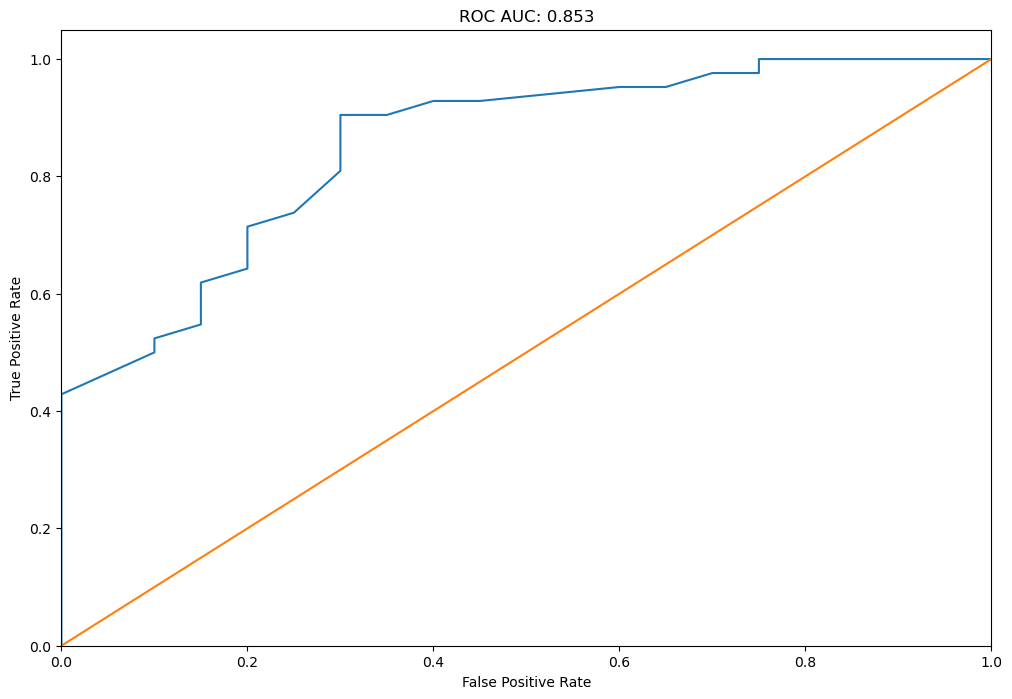

In [35]:
plot_roc_curve(knn.predict_proba(X_test_scaled)[:, 1], y_test)

## Мультиклассовая регрессия

Для обучения модели предсказывать $K$ классов можно натренировать $K$ классификаторов 1 против всех (one vs rest) и при предсказании брать максимальное значение. Вероятности нормализуются. Или $K(K-1)/2$ классификаторов one vs one.

Рассмотрим другой способ - softmax.

Нам необходимо получить значения для $k$ классов - составим матрицу параметров $\Theta$


$$ x = \begin{bmatrix} 1 & x_{11} & ... & x_{p1} \\ 1 & x_{12} & ... & x_{p2} \\ ... & ... & ... & ... \\ 1 & x_{n1} & ... & x_{n1}
\end{bmatrix} \quad 
\Theta = \begin{bmatrix} \theta_{01} &  ... & \theta_{0k} \\ \theta_{11} & ... & \theta_{1k} \\ ... & ... & ... \\ \theta_{p1} & ... & \theta_{pk} \end{bmatrix} \quad 
f = \begin{bmatrix} f_{01} &  ... & f_{0k} \\ f_{11} & ... & f_{1k} \\ ... & ... & ... \\ f_{n1} & ... & f_{nk}\end{bmatrix} $$

## Softmax

$$ \hat{p}_k = \frac{e^{x\theta_k}}{\sum_{j=1}^K e^{x\theta_j}} $$

$$ \hat{y}_k = {argmax}_k \hat{p}_k$$

## Оценка для случая многих классов - cross entropy

$$Q(\Theta, x) = - \frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K} y_{ik} \log \hat{p}_{ik}$$

In [42]:
from sklearn import linear_model, datasets
iris = datasets.load_iris()

X = iris.data[:, :2] # Мы учитываем только первые две характеристики
Y = iris.target

print(X[:10])
print(np.unique(Y))

logreg = linear_model.LogisticRegression(C=1e5)

logreg.fit(X, Y)

[[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]
 [5.4 3.9]
 [4.6 3.4]
 [5.  3.4]
 [4.4 2.9]
 [4.9 3.1]]
[0 1 2]


,penalty,'l2'
,dual,False
,tol,0.0001
,C,100000.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [43]:
logreg.coef_

array([[-36.62098699,  30.94058007],
       [ 17.3603161 , -15.67426998],
       [ 19.26067089, -15.26631009]])

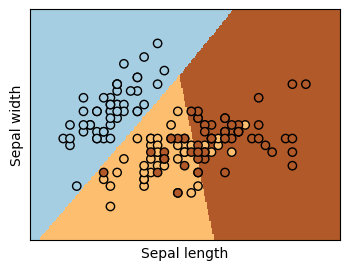

In [46]:
h = .02 # Шаг изменения сетки
# Построим границу принятия решения. Для этого присвоим цвет каждой точке сетки:
# [x_min, x_max]x[y_min, y_max].
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])

# Вывести результат на цветовой график
Z = Z.reshape(xx.shape)
plt.figure(1, figsize=(4, 3))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)

# Также отобразить точки тренировки
plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())
plt.show()

In [47]:
Z = logreg.predict_proba(np.c_[xx.ravel(), yy.ravel()])
np.set_printoptions(precision=3, suppress=True)
print(Z[:10])
print(logreg.coef_)
print(logreg.intercept_)

[[0.999 0.001 0.   ]
 [0.997 0.003 0.   ]
 [0.99  0.01  0.   ]
 [0.971 0.029 0.   ]
 [0.919 0.081 0.001]
 [0.793 0.205 0.001]
 [0.566 0.431 0.003]
 [0.307 0.688 0.005]
 [0.131 0.863 0.006]
 [0.049 0.944 0.007]]
[[-36.621  30.941]
 [ 17.36  -15.674]
 [ 19.261 -15.266]]
[ 98.985 -42.971 -56.014]
